# CMAPSS FD001 — Exploratory Data Analysis

## Objectives
- Understand the CMAPSS FD001 dataset structure and quality
- Analyze sensor behavior and degradation patterns over engine life
- Compute Remaining Useful Life (RUL) and analyze its distribution
- Identify informative sensors via variance and correlation analysis
- Define a feature selection strategy for downstream preprocessing

## Problem Context

The CMAPSS dataset simulates aircraft engine degradation trajectories.

The objective is to estimate Remaining Useful Life (RUL)
using multivariate sensor measurements collected over time.

This type of problem is common in:
- predictive maintenance
- industrial monitoring
- aerospace reliability systems

## Environment and Library Setup

In [5]:
from logging import warning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
sys.path.append("..") # Original line
sys.path.append("../src") # Add the src directory directly to the path
from data_loader import load_train_data # Modified import
from preprocessing import add_rul # Modified import
import joblib
pd.set_option("display.max_columns", None)
plt.rcParams['figure.figsize'] = (8, 5)
warnings.filterwarnings("ignore")

## Load dataset

CMAPSS files are whitespace-separated text files without headers.
We manually assign column names.

In [6]:
df_raw = load_train_data("../data/raw/train_FD001.txt")

df_raw.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Dataset shape

Check number of rows and columns.

In [7]:
df_raw.shape

(20631, 26)

## Data quality check

Verify:
- missing values
- duplicate rows
- empty rows
- sensor variance
- cycle consistency

In [8]:
df = df_raw.copy()

### Missing values

Check for null or missing observations.

In [9]:
missing_values = df_raw.isnull().sum()
print(f"Missing values: {missing_values.sum()}")

if missing_values.sum() > 0:
    print("Missing values:")
    print(missing_values)

Missing values: 0


### Duplicate rows

Check for duplicated observations.

In [10]:
duplicates = df_raw.duplicated().sum()
print("Duplicate rows:", duplicates)
if duplicates > 0:
    print("Duplicate rows:")
    print(df_raw[df_raw.duplicated()])
    df = df_raw.drop_duplicates()

Duplicate rows: 0


### Empty rows

Check for completely empty observations.

In [11]:
empty_rows = df_raw[df_raw.isnull().all(axis=1)]
print("Completely empty rows:", len(empty_rows))
if len(empty_rows) > 0:
    print("Completely empty rows:")
    print(empty_rows)
    df = df_raw.dropna(how='all')

Completely empty rows: 0


### Dataset info

Inspect datatypes and memory usage.

In [12]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   sensor_1   20631 non-null  float64
 6   sensor_2   20631 non-null  float64
 7   sensor_3   20631 non-null  float64
 8   sensor_4   20631 non-null  float64
 9   sensor_5   20631 non-null  float64
 10  sensor_6   20631 non-null  float64
 11  sensor_7   20631 non-null  float64
 12  sensor_8   20631 non-null  float64
 13  sensor_9   20631 non-null  float64
 14  sensor_10  20631 non-null  float64
 15  sensor_11  20631 non-null  float64
 16  sensor_12  20631 non-null  float64
 17  sensor_13  20631 non-null  float64
 18  sensor_14  20631 non-null  float64
 19  sensor_15  20631 non-null  float64
 20  sensor

### Sensor variance analysis

Identify sensors with very low variability.
Low-variance sensors may not provide useful information.

In [13]:
sensor_cols = [col for col in df.columns if "sensor" in col]
variance_df = (df_raw[sensor_cols].var().sort_values())

variance_df

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,2.422479e-28
sensor_10,2.172333e-25
sensor_5,1.152399e-23
sensor_1,4.273435e-21
sensor_6,1.929279e-06
sensor_15,1.406628e-03
sensor_8,5.038938e-03
sensor_13,5.172330e-03


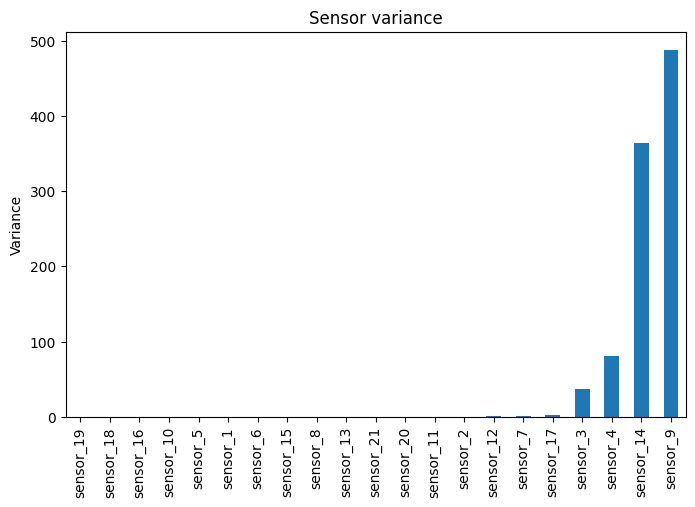

In [14]:
variance_df.plot(kind="bar")

plt.title("Sensor variance")
plt.ylabel("Variance")

plt.show()

For a better view we apply the log scale for the y-axes

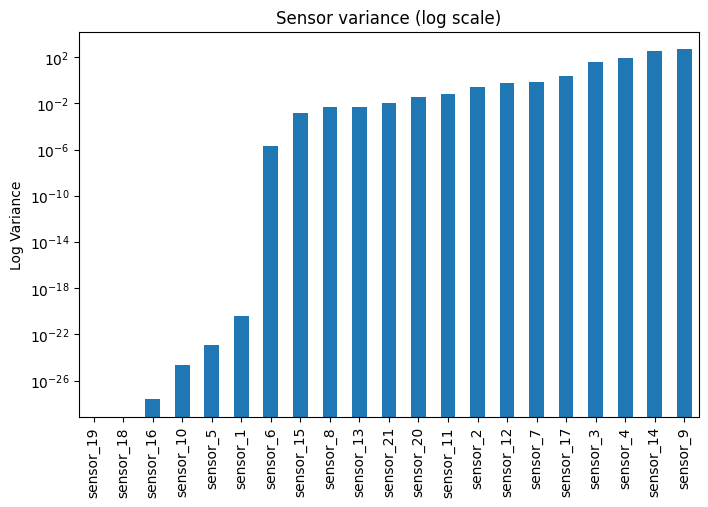

In [15]:
variance_df.plot(kind="bar", logy=True)

plt.title("Sensor variance (log scale)")
plt.ylabel("Log Variance")

plt.show()

In [16]:
low_variance_candidates = variance_df[variance_df < 1e-2].index.tolist()
print(low_variance_candidates)

['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1', 'sensor_6', 'sensor_15', 'sensor_8', 'sensor_13']


**Observations**:
- Several sensors exhibit near-zero variance
- These sensors are likely uninformative for predictive modeling
- Variance distribution spans multiple orders of magnitude

For this reason, these sensors could be removed during preprocessing.

### Cycle consistency

Verify that engine cycles start correctly.

In [17]:
df.groupby("engine_id")["cycle"].min().value_counts()

,count
cycle,
1,100


## Data Quality Summary
Observations:
- no missing values detected
- no duplicate rows detected
- all engines start from cycle 1
- several sensors show very low variance

Implications:
- low-variance sensors may be removed during preprocessing
- no imputation strategy is currently required

## Dataset overview

Understand how many engines and cycles are available.

In [18]:
print(f"Engines: {df['engine_id'].nunique()}")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Engines: 100
Total rows: 20631
Total columns: 26


In [19]:
cycle_stats = df.groupby("engine_id")["cycle"].max()
print("Engine lifetime (cycles):")
print(cycle_stats.describe().round(1))

Engine lifetime (cycles):
count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: cycle, dtype: float64


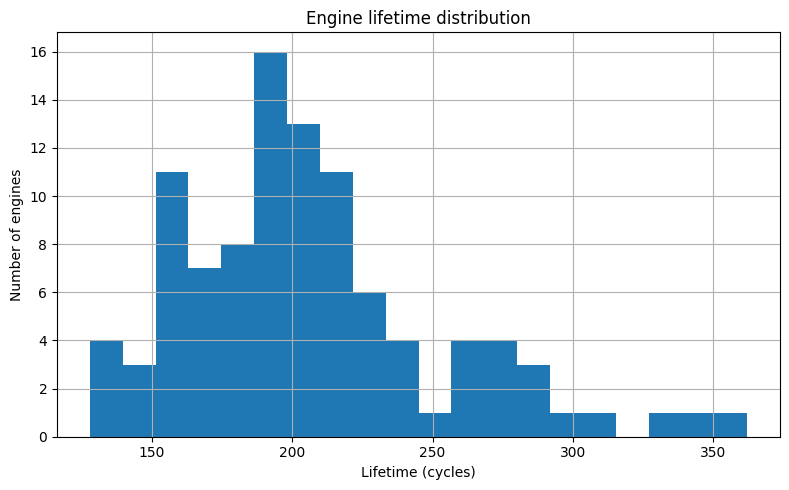

In [20]:
cycle_stats.hist(bins=20)
plt.xlabel("Lifetime (cycles)")
plt.ylabel("Number of engines")
plt.title("Engine lifetime distribution")
plt.tight_layout()
plt.show()

## Sensor behavior over time

Visualize sensor degradation for a single engine.

In [21]:
# Sensors selected for visualization: representative of high-variance
selected_sensors = ["sensor_2", "sensor_7", "sensor_11", "sensor_12"]

In [22]:
engine = 1
subset = df[df["engine_id"] == engine]

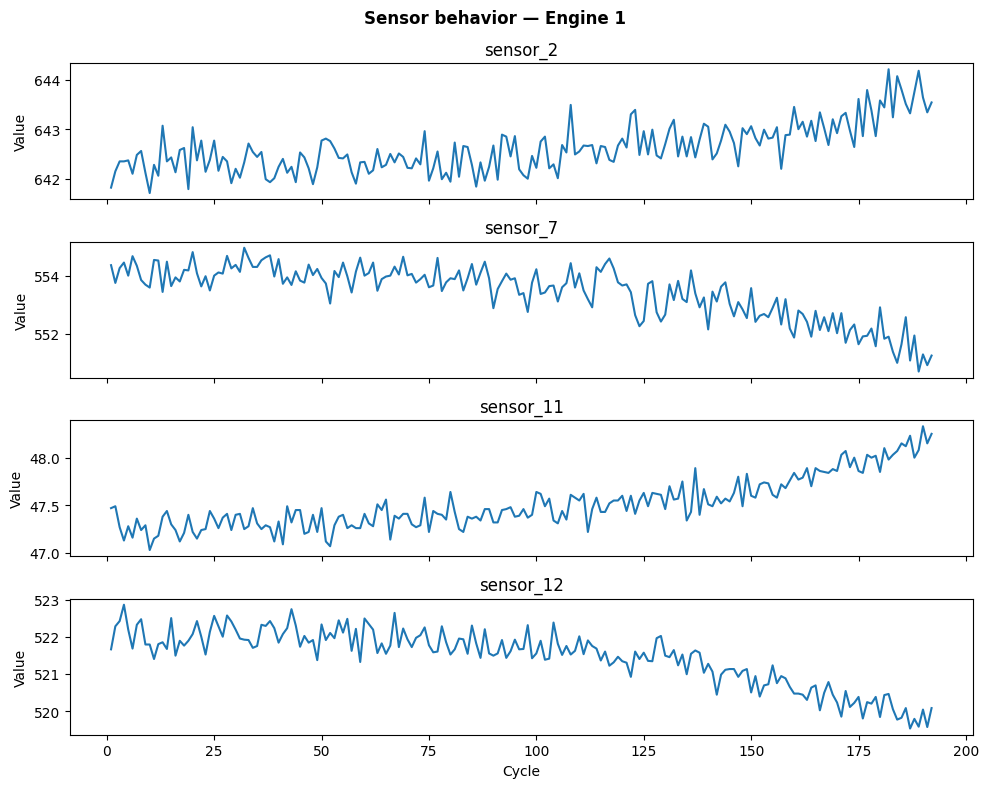

In [23]:
fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(10, 8), sharex=True)
for i, sensor in enumerate(selected_sensors):
    axes[i].plot(subset["cycle"], subset[sensor])
    axes[i].set_title(sensor)
    axes[i].set_ylabel("Value")
plt.xlabel("Cycle")
plt.suptitle(f"Sensor behavior — Engine {engine}", fontweight="bold")
plt.tight_layout()
plt.show()

**Observations**:
- Some sensors show smoother degradation trajectories
- Others remain relatively stable over time
- Temporal dynamics differ significantly across sensors

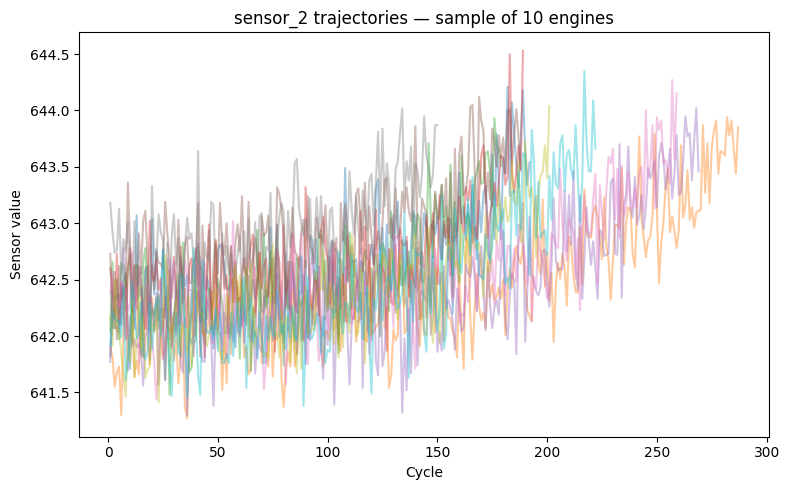

In [24]:
sample_engines = df["engine_id"].unique()[:10]
sensor = "sensor_2"

for eng in sample_engines:
    subset = df[df["engine_id"] == eng]
    plt.plot(subset["cycle"], subset[sensor], alpha=0.4)

plt.title(f"{sensor} trajectories — sample of {len(sample_engines)} engines")
plt.xlabel("Cycle")
plt.ylabel("Sensor value")
plt.tight_layout()
plt.show()

**Observations**:
- Sensor trajectories vary significantly across engines
- Degradation patterns are not identical between units
- Inter-engine variability is present throughout the entire lifecycle

In [25]:
# Normalize cycle to [0, 1] per engine to make trajectories comparable
df["life_pct"] = df["cycle"] / df.groupby("engine_id")["cycle"].transform("max")
df["life_pct_bin"] = pd.cut(df["life_pct"], bins=20)

In [26]:
for sensor in selected_sensors:
    df[f"{sensor}_norm"] = df.groupby("engine_id")[sensor].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()))
selected_sensors_norm = [f"{s}_norm" for s in selected_sensors]

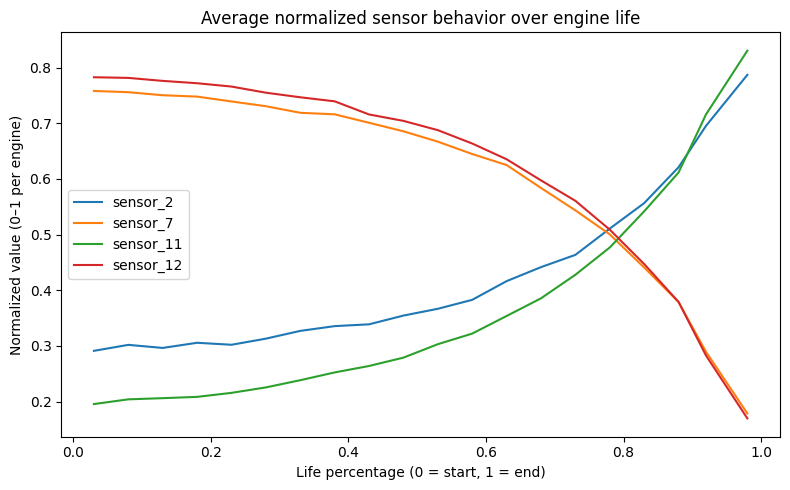

In [27]:
mean_sensor = df.groupby("life_pct_bin")[selected_sensors_norm].mean()
mean_sensor.index = [round(i.mid, 2) for i in mean_sensor.index]
mean_sensor.columns = selected_sensors

mean_sensor.plot()
plt.title("Average normalized sensor behavior over engine life")
plt.xlabel("Life percentage (0 = start, 1 = end)")
plt.ylabel("Normalized value (0–1 per engine)")
plt.tight_layout()
plt.show()

**Observations:**
- After per-engine min-max normalization, degradation trends emerge clearly
- sensor_2 and sensor_11 increase monotonically toward end of life, indicating progressive wear
- sensor_7 and sensor_12 decrease monotonically, confirming inverse degradation behavior
- All 4 sensors accelerate their trend in the final 20% of engine life (life_pct > 0.8), suggesting a critical degradation phase near failure

## Remaining Useful Life (RUL)

RUL is computed as:

\begin{aligned}
\text{max cycle for engine - current cycle}
\end{aligned}


In [28]:
df = add_rul(df)

In [29]:
df[["engine_id", "cycle", "RUL"]].head()

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


### RUL distribution

Analyze target distribution.

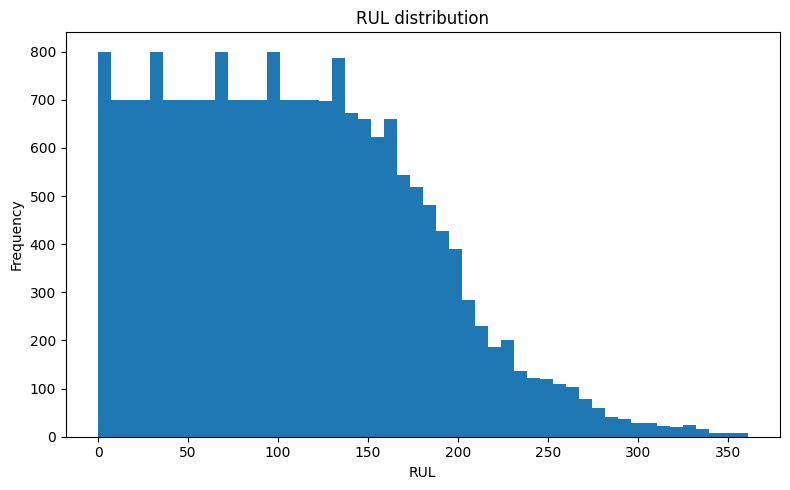


RUL range: 0 – 361
Mean RUL: 107.8
Median RUL: 103.0


In [30]:
plt.hist(df["RUL"], bins=50)
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.title("RUL distribution")
plt.tight_layout()
plt.show()

print()
print(f"RUL range: {df['RUL'].min()} – {df['RUL'].max()}")
print(f"Mean RUL: {df['RUL'].mean():.1f}")
print(f"Median RUL: {df['RUL'].median():.1f}")

**Observations:**
- RUL ranges from 0 (last cycle before failure) to 361
- The distribution is right-skewed: many cycles have low RUL,
  few have very high RUL
- High RUL values (> 125) may be less informative for maintenance decisions — a cap at 125 will be applied during preprocessing to focus the model on the critical degradation window

## Sensor-RUL analysis

### Life Phase analysis

In [31]:
df["life_phase"] = pd.cut(df["life_pct"],
                          bins=[0, 0.33, 0.66, 1.0],
                          labels=["early", "mid", "late"],
                          include_lowest=True)
round(df.groupby("life_phase")[sensor_cols].mean().T, 2)

life_phase,early,mid,late
sensor_1,518.67,518.67,518.67
sensor_2,642.39,642.54,643.09
sensor_3,1587.06,1588.86,1595.44
sensor_4,1402.99,1406.22,1417.24
sensor_5,14.62,14.62,14.62
sensor_6,21.61,21.61,21.61
sensor_7,553.92,553.64,552.57
sensor_8,2388.06,2388.08,2388.15
sensor_9,9056.54,9060.37,9078.27
sensor_10,1.30,1.30,1.30


**Observations:**
- Life phase is now assigned per engine based on normalized life percentage, avoiding the bias introduced by engines with different lifetimes
- Sensors showing monotonic change across phases (e.g. sensor_2, sensor_4, sensor_11) are strong degradation indicators
- Sensors with identical values across all phases confirm zero informativeness

### Correlation RUL-Sensors

In [32]:
corr_per_engine = (df.groupby("engine_id")
                     .apply(lambda g: g[sensor_cols + ["RUL"]]
                     .corr()["RUL"]
                     .drop("RUL")))

In [33]:
mean_corr = corr_per_engine.mean().sort_values()

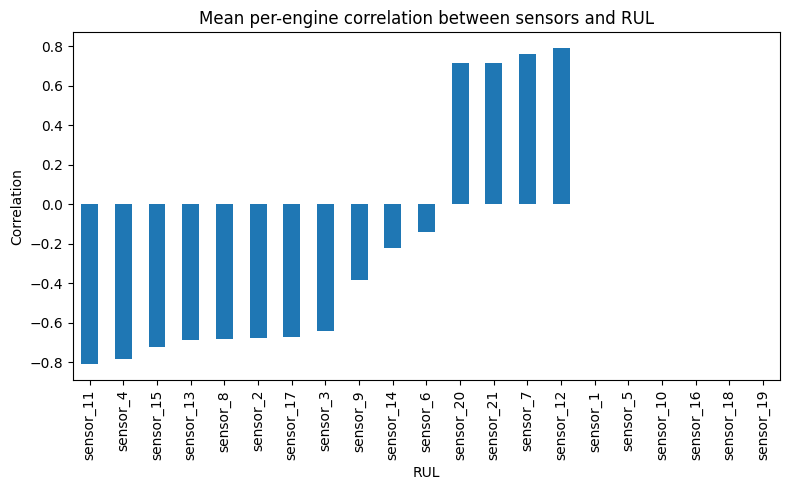

In [34]:
mean_corr.plot(kind="bar")
plt.title("Mean per-engine correlation between sensors and RUL")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

**Observations**:
- Several sensors show strong correlation with RUL
- Both positive and negative relationships are present
- Some sensors appear weakly informative and may be excluded

## Feature Selection Decisions

In [35]:
low_variance_candidates = variance_df[variance_df < 1e-2].index.tolist()
corr_abs = mean_corr.abs().fillna(0)

In [36]:
low_variance_sensors = [s for s in low_variance_candidates if corr_abs[s] < 0.1]

In [37]:
selected_sensors = [s for s in sensor_cols if s not in low_variance_sensors]

In [38]:
low_variance_sensors

['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1']

In [39]:
print(f"Removed sensors: {low_variance_sensors}")
print(f"Selected sensors: {selected_sensors}")

Removed sensors: ['sensor_19', 'sensor_18', 'sensor_16', 'sensor_10', 'sensor_5', 'sensor_1']
Selected sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


**Observations:**
- Sensors are removed only if they show both low variance and low
  correlation with RUL — a single criterion is insufficient
- sensor_8 and sensor_13 are retained despite low variance,
  as they carry a meaningful correlation signal
- The final selected_sensors list is passed to preprocessing

## EDA Summary
- Data Quality
  - No missing values, duplicates, or empty rows detected
  - All engines start from cycle 1
  - Dataset is clean and ready for preprocessing
- Sensor Behavior
  - Sensor trajectories vary across engines — degradation is not uniform
  - After per-engine normalization, 4 sensors show clear monotonic trends: sensor_2 and sensor_11 increase toward end of life,     sensor_7 and sensor_12 decrease
  - All 4 sensors accelerate their trend in the final 20% of engine life
- Feature Selection
  - Sensors removed: low variance AND low correlation with RUL
  - sensor_8 and sensor_13 retained despite low variance (correlation > 0.6)
  - Final selected sensors passed to preprocessing notebook
- RUL Distribution
  - RUL ranges from 0 to 361, right-skewed distribution
  - A cap at 125 cycles will be applied in preprocessing to focus     the model on the critical degradation window

These findings will guide the preprocessing and feature engineering
pipeline implemented in the next notebook.

## Next Steps
- Apply RUL cap at 125 cycles
- Normalize sensors using the selected sensor list
- Add rolling and lag features
- Build RUL forecasting and anomaly detection models

## Save interim dataset

Save processed dataset for next stages.

In [40]:
cols_to_save = [c for c in df.columns
                if c not in ["life_pct", "life_pct_bin", "life_phase"] +
                             [f"{s}_norm" for s in selected_sensors]]

In [41]:
df[cols_to_save].to_parquet("../data/interim/train_fd001_eda.parquet", index=False)
joblib.dump(selected_sensors, "../outputs/selected_sensors.pkl")

print("Saved: train_fd001_eda.parquet")
print(f"Saved: selected_sensors.pkl → {selected_sensors}")

Saved: train_fd001_eda.parquet
Saved: selected_sensors.pkl → ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
